In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from matplotlib.lines import Line2D

In [24]:
df = pd.read_csv('ASEAN.csv')
df = df.iloc[:-5]
df = df.replace("..", pd.NA)

In [25]:
year_cols = [col for col in df.columns if "YR" in col]

df_long = df.melt(
    id_vars=["Country Name", "Country Code", "Series Name", "Series Code"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Value"
)

df_long["Year"] = df_long["Year"].str.extract(r'(\d{4})').astype(int)

df_long["Value"] = pd.to_numeric(df_long["Value"], errors="coerce")

df_long = df_long.sort_values("Year")

df_long["Value"] = df_long.groupby(
    ["Country Name", "Series Name"]
)["Value"].transform(lambda x: x.interpolate().ffill().bfill())

df_final = df_long.pivot_table(
    index=["Country Name", "Year"],
    columns="Series Name",
    values="Value",
    aggfunc="mean"
).reset_index()

df_final = df_final.sort_values(["Country Name", "Year"])

## Subgroup: Health, longevity

#### 1. How has life expectancy changed among East Asian countries between 2000 and 2020?

- **Data field:** 
  - `Life expectancy at birth, total (years)`: This field contains values that representing the average lifespan of a person, calculated in years. This field will show the life expectancy of different countries year by year, thereby revealing trends.
  - `Year`: This field contains values ​​representing calendar years. It will help our identify the timelines.
  - `Country Name`: This field contains values representing name of countries in Southeast Asia. These are the subjects that need to be studied for this objective.
- **Chart type:** Line chart (X-axis is `Year`, Y-Axis is value of `Life expectancy at birth, total (years)`, Line is `Country Name`) because this type of chart will best assist readers in understanding trends and changes in data over time.
- **Expected insight:** The assessment examines the differences in life expectancy between countries, as well as how life expectancy changes in these countries over the years.

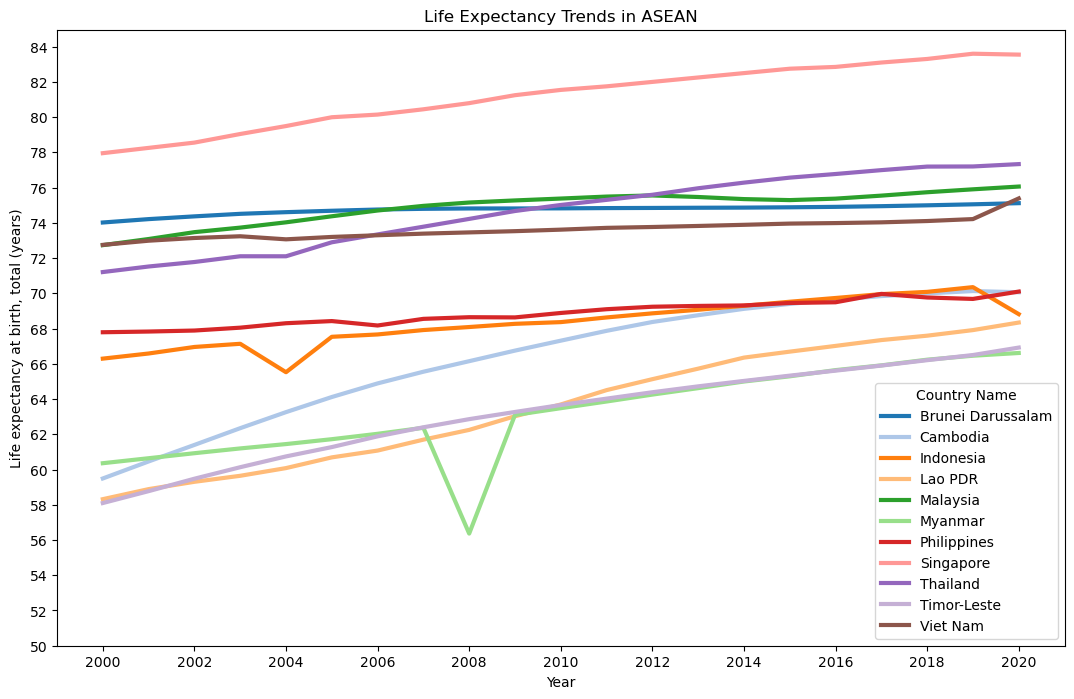

In [26]:
plt.figure(figsize=(13,8))

sns.lineplot(
    data=df_final,
    x="Year",
    y="Life expectancy at birth, total (years)",
    hue="Country Name",
    palette="tab20",
    linewidth=3
)

plt.xticks(range(2000, 2021, 2))
plt.yticks(range(50, 85, 2))
plt.title("Life Expectancy Trends in ASEAN")
plt.show()

- **Overview analysis:**
  - All ASEAN countries showed an upward trend in life expectancy during the period 2000–2020.
  - The gap between developed countries (Singapore, Brunei) and developing countries (Laos, Myanmar, Cambodia) still exists but shows signs of narrowing.
  - The increase is uneven across countries:
    - Some countries experienced stable growth (Vietnam, Thailand, Malaysia)
    - Some experienced fluctuations (Myanmar, Indonesia)

- **Observations and trends drawn from the data:** Based on the chart, life expectancy can be divided into 4 groups:
  - The very high life expectancy group (≥75 years) includes Singapore: There is a significant difference compared to other countries, where life expectancy reached 78 years in the 2000s and has steadily increased to around 84 years. This country is a developed, high-income country, so its healthcare system, environment, and quality of life are all good, making a high life expectancy understandable.
  - The high life expectancy group (≥70 years) includes Vietnam, Thailand, Brunei, Malaysia:
    - This group experienced fairly steady growth, but not explosive growth, lasting only about 2-4 years out of 20.
    - Thailand had the best growth rate, increasing the age from 71 to 76.
    - The remaining countries typically only increase rates every 2 years.
    - These countries are developing nations or developed nations with a moderately high quality of life and healthcare, resulting in a steady increase in life expectancy.
  - The moderate life expectancy group (68–72 years) includes Philippines and Indonesia: Slight increase, with small fluctuations. Indonesia has a small decrease in 2004. This group has seen an increase in life expectancy, but it is not yet significant. This group has seen growth in life expectancy, but it is not yet significant, possibly due to its relatively large population and the lack of investment in quality of life and infrastructure.
  - Short age group (≤60 years old) includes Cambodia, Timor-Leste, Laos, Myanmar. 
    - These countries all have low incomes compared to the region, but their relatively rapid growth rates may stem from the beginning of investments in public health.
    - Cambodia has seen a very rapid increase in life expectancy, from 59 to 68 years, placing it in the same group as other countries with average life expectancy.
    - Myanmar experienced a significant decrease in life expectancy in 2008, falling from approximately 61 to 56 years. This could be attributed to a major external influence on the country, as life expectancy then stabilized in 2009, similar to 2007.
- **Inclusion:** 
  - The quality of life in ASEAN is improving significantly as life expectancy increases in all countries.
  - The development gap still exists but is narrowing.

#### 2. Many believe that life expectancy is linked to the quality of healthcare, which in turn is linked to economic development and healthcare spending. Is this view entirely accurate?

- **Data field:** 
  - `Life expectancy at birth, total (years)`: This field contains values that representing the average lifespan of a person, calculated in years. This field will show the life expectancy of different countries year by year. This forms the basis for identifying influencing factors.
  - `GDP (current US$)`: This field contains values that representing the average income per person in a year. The reason for choosing this attribute is that it is a crucial element in the hypothesis about a binding relationship between economics and health.
  - `GDP growth (annual %)`: This field contains values ​​representing economic growth in the current year compared to the previous year. Economic growth will improve many aspects of a country's infrastructure and quality of life.
  - `Current health expenditure per capita, PPP (current international $)`: This field contains values representing the amount of money an average person spends on healthcare expenses in a year. This cost reflects the money spent by individuals, not the government.
  - `Current health expenditure (% of GDP)`: This field contains values representing percentage of government spending on healthcare. This attribute will indicate how the amount of money the government spends will affect the situation. The reason for choosing this column is the same as the one above.
  - `Domestic general government health expenditure (% of general government expenditure)`: This field contains values representing percentage of government spending on healthcare out of total domestic expenditure. 
- **Chart type:** 
  - Heatmap chart (The values ​​in this graph will represent the correlation between the data fields) because this chart will show the correlation between economic factors and life expectancy.
  - Bubble chart (X-Axis is value of `Domestic general government health expenditure (% of general government expenditure)`, Y-Axis is value of `Life expectancy at birth, total (years)`, each color represents a different `Country` and each key point represents a recorded line of data) This chart will show how effective investing in healthcare can be.
- **Expected insight:** Assess how economic factors will impact life expectancy in these countries.

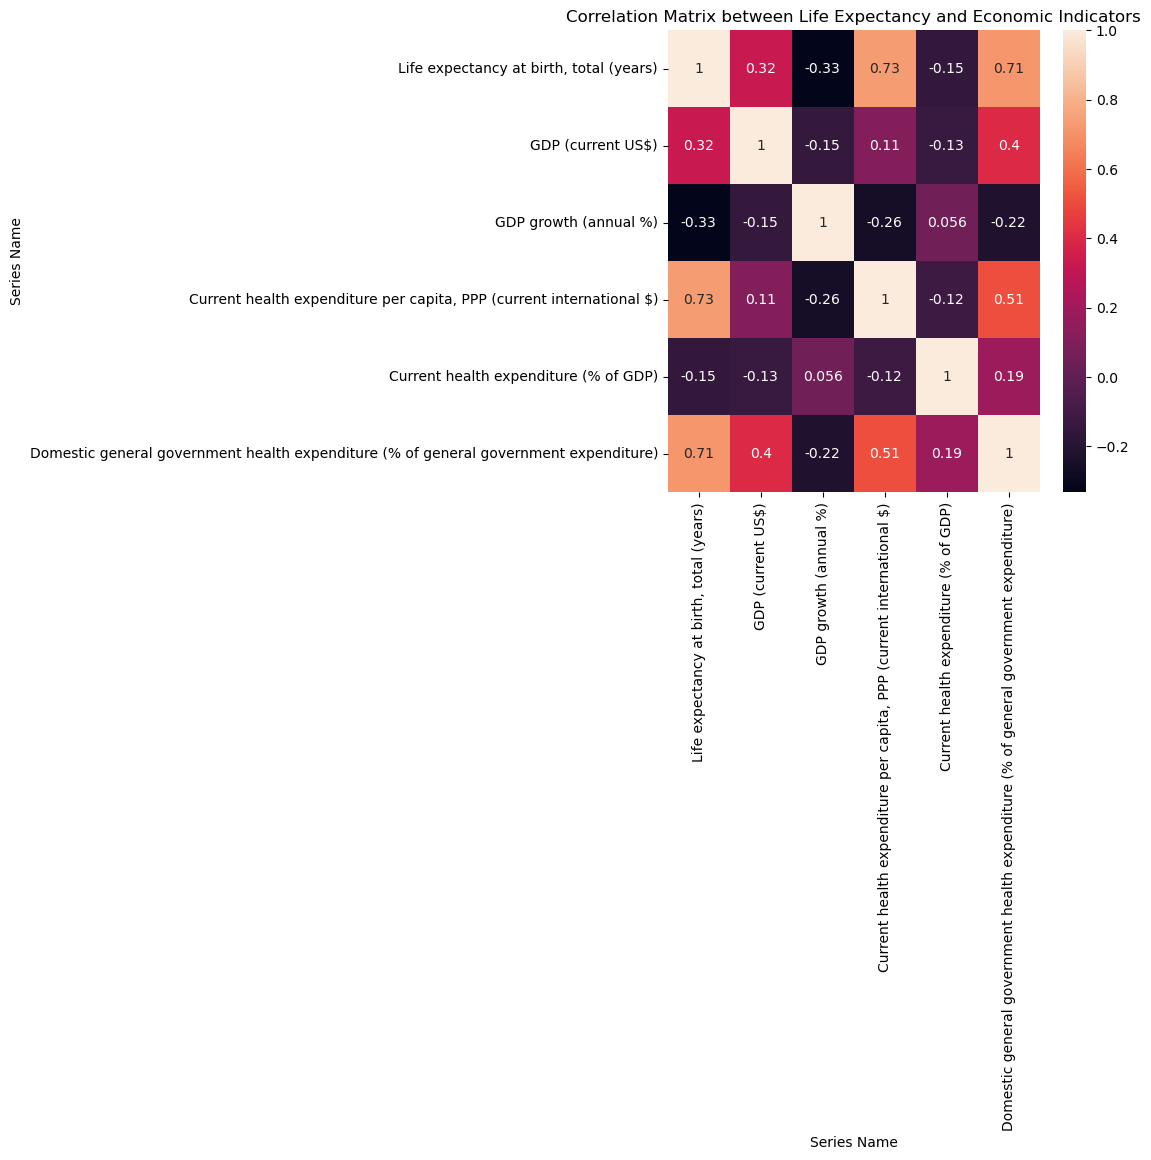

In [27]:
cols = [
    "Life expectancy at birth, total (years)",
    "GDP (current US$)",
    "GDP growth (annual %)",
    "Current health expenditure per capita, PPP (current international $)", 
    "Current health expenditure (% of GDP)",
    "Domestic general government health expenditure (% of general government expenditure)",
]

plt.figure(figsize=(6,6))
sns.heatmap(df_final[cols].corr(), annot=True)

plt.title("Correlation Matrix between Life Expectancy and Economic Indicators")
plt.show()

- **Overview analysis:** In general, not all economic factors that increase lead to improved life expectancy.

- **Observations and trends drawn from the data:**
  - We can see that life expectancy is significantly influenced by two main factors: Current health expenditure per capita, PPP (current international $), and Domestic general government health expenditure (% of general government expenditure). These two factors are the two key elements that determine the level of health awareness among individuals and the government.
  - There is a slight correlation between GDP and life expectancy, which is understandable given that an increase in GDP leads to an improvement in quality of life.
  - There is a paradox: when GDP growth (annual %) and current health expenditure (% of GDP) increase, life expectancy decreases. While growth rates are often associated with developing countries, an increase in economic growth doesn't necessarily correlate positively with life expectancy. Furthermore, the percentage of spending relative to GDP doesn't fully reflect whether the money spent has significantly improved healthcare.
- **Inclusion:** 
  - The awareness of the importance of healthcare among both the public and the government is a crucial factor in determining whether life expectancy will improve.
  - GDP growth is also a contributing factor, but it will not be the most important one, to life expectancy.

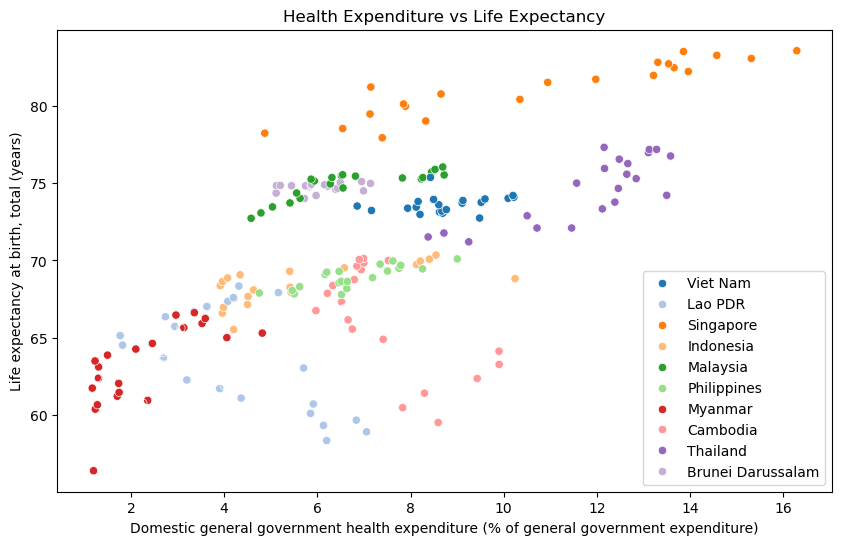

In [28]:
my_order = ["Viet Nam", "Lao PDR", "Singapore", "Indonesia", "Malaysia", "Philippines", "Myanmar", "Cambodia", "Thailand", "Brunei Darussalam"]

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_final,
    x="Domestic general government health expenditure (% of general government expenditure)",
    y="Life expectancy at birth, total (years)",
    hue="Country Name",
    palette="tab20",
    hue_order = my_order
)
plt.legend(loc='lower right')
plt.title("Health Expenditure vs Life Expectancy")
plt.show()

- **Overview analysis:** Overall, a higher ratio of investment in the economy to total government domestic spending will lead to improved life expectancy in countries.

- **Observations and trends drawn from the data:** The groups of countries in this chart are clustered in a way that closely resembles the life expectancy trend mentioned in the question above.
  - We can see that Singapore consistently allocates between 4% and 16% of its spending to healthcare, which not only contributes to their high life expectancy but also significantly improves their overall well-being.
  - The significant improvement in life expectancy in Thailand, mentioned in the question above, can be explained by the fact that their spending at times reached 14%, much higher than other countries in the same group.
  - In the remaining groups, the proportion of investment in healthcare is generally very similar, but paradoxically, Cambodia, at one point, spent around 10% in this sector, yet their life expectancy has not exceeded 65 years (much lower than many countries with similar proportions).
- **Inclusion:** 
  - Government healthcare spending has a positive impact on life expectancy.
  - This relationship is strong but not perfect, as there are cases where significant investment in health doesn't yield overwhelmingly positive results.

#### 3. Above, we have made a general comparison of life expectancy across countries. Now, how do factors contributing to death, such as traffic accidents, non-hereditary diseases, or substance abuse like alcohol, differ in these countries?

- **Data field:** 
  - `Mortality caused by road traffic injury (per 100,000 population)`: This field contains values that representing the number of traffic accident fatalities per 100,000 people in a year. The issue of fatalities due to traffic accidents is a matter that needs attention in order to assess whether the traffic infrastructure and laws in these countries are truly effective.
  - `Mortality from CVD, cancer, diabetes or CRD between exact ages 30 and 70 (%)`: This field contains values that representing the percentage of people who develop non-communicable diseases such as heart disease, cancer, diabetes, or CRD in a given year. This attribute can indicate the prevalence of common non-communicable diseases in various countries.
  - `Total alcohol consumption per capita (liters of pure alcohol, projected estimates, 15+ years of age)`: This field contains values that representing the average amount of alcohol consumed by people over 15 years old in a year. Comparing alcohol content helps determine the impact of alcohol on health.
  - `Year`: This field contains values that representing the calendar year. Here, only the years 2000 and 2020 are used to show how much has changed.
- **Chart type:** 
  - Group bar chart (X-Axis is value of `Country Name`, Y-Axis is value of `Mortality caused by road traffic injury (per 100,000 population)`) This chart will show the changes and comparisons in the number of traffic accident fatalities in different countries over the past 20 years.
  - Group bar chart (X-Axis is value of `Country Name`, Y-Axis is value of `Mortality from CVD, cancer, diabetes or CRD between exact ages 30 and 70 (%)`) This chart will show the changes and comparisons in the the mortality rate from diseases such as cardiovascular disease, cancer, and diabetes. in different countries over the past 20 years.
  - Group bar chart (X-Axis is value of `Country Name`, Y-Axis is value of `Total alcohol consumption per capita (liters of pure alcohol, projected estimates, 15+ years of age)`) This chart will show the changes and comparisons in the average amount of alcohol consumed by people over 15 years old in different countries over the past 20 years.
- **Expected insight:** AIt is possible to compare and relate life expectancy across countries to the factors believed to influence it.

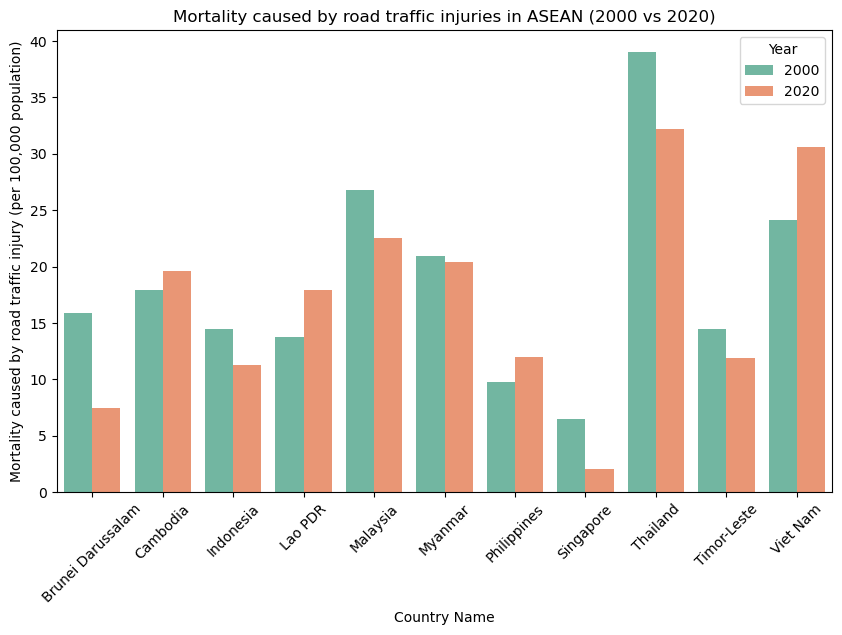

In [29]:
df_traffic = df_final[df_final["Year"].isin([2000, 2020])]
plt.figure(figsize=(10,6))
sns.barplot(
    data=df_traffic,
    x="Country Name",
    y="Mortality caused by road traffic injury (per 100,000 population)",
    hue="Year",
    palette="Set2"
)
plt.title("Mortality caused by road traffic injuries in ASEAN (2000 vs 2020)")
plt.xticks(rotation=45)
plt.show()

- **Overview analysis:** It can be seen that 7 out of 11 countries showed improvement in mortality rates, but as many as 4 countries experienced a slight increase in mortality rates.

- **Observations and trends drawn from the data:**
  - Mortality rates in countries like Thailand, Vietnam, and Malaysia are quite high. These are countries that belong to the group with high life expectancy in the region.
  - Meanwhile, smaller countries like Brunei or Singapore, or island nations like Indonesia and the Philippines, have low mortality rates.
  - Countries that have shown significant improvement in mortality rates, such as Singapore, Thailand, Malaysia, and Brunei, all have high to very high life expectancy, and these countries have also seen improvements in life expectancy as previously analyzed. This can be seen as a factor that influences life expectancy to some extent.
  - Countries that have shown improvement in low mortality rates tend to be in the middle- and lower life expectancy groups.  
  - However, the increase in mortality rates comes from countries such as Vietnam, Cambodia, Laos, and the Philippines. Among these, Vietnam has a high life expectancy in the region, as analyzed above, while Cambodia has seen relatively significant improvement in life expectancy. Therefore, in these countries, traffic accidents may not yet be a major issue affecting life expectancy.
- **Inclusion:** While mortality rates vary between countries, their overall impact on life expectancy is not significant, as many cases of inverse correlation still exist.

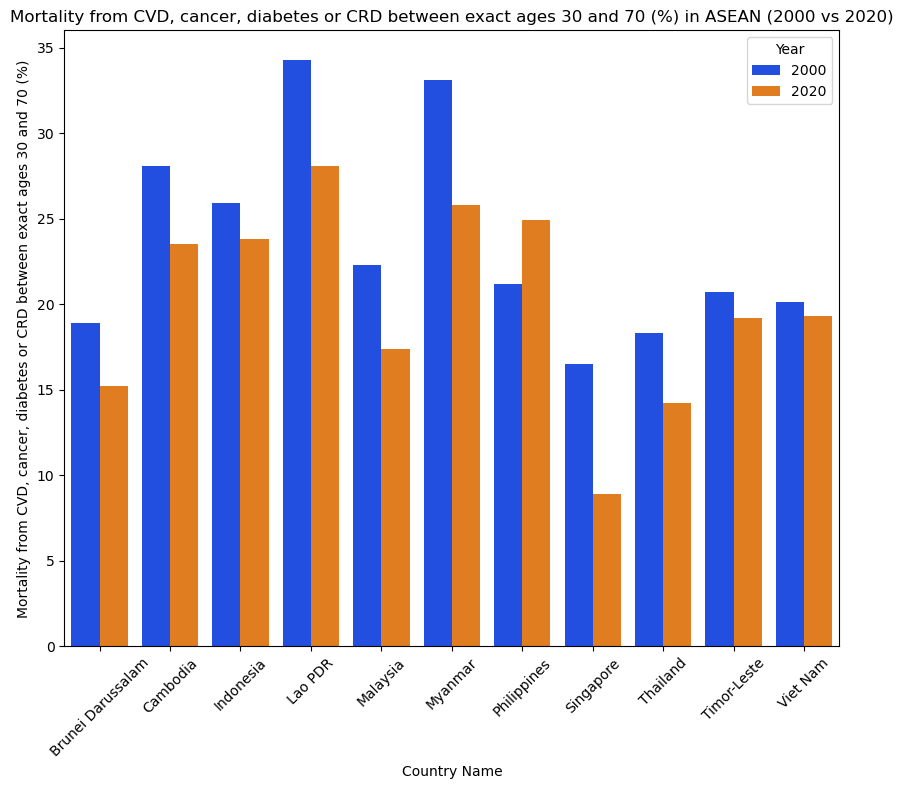

In [30]:
df_traffic = df_final[df_final["Year"].isin([2000, 2020])]
plt.figure(figsize=(10,8))
sns.barplot(
    data=df_traffic,
    x="Country Name",
    y="Mortality from CVD, cancer, diabetes or CRD between exact ages 30 and 70 (%)",
    hue="Year",
    palette="bright"
)
plt.title("Mortality from CVD, cancer, diabetes or CRD between exact ages 30 and 70 (%) in ASEAN (2000 vs 2020)")
plt.xticks(rotation=45)
plt.show()

- **Overview analysis:** Ten out of eleven countries showed improvement in mortality rates for this group of diseases, indicating that the region is investing in health and other issues such as quality of life.

- **Observations and trends drawn from the data:**
  - Laos and Myanmar had high mortality rates from this group of diseases compared to the region in 2000, indicating that these two countries had not invested well in healthcare at that time. However, after 20 years, the gap has narrowed compared to the rest of the countries.
  - These two countries also saw a significant reduction in mortality rates, decreasing by 6-7%, which could be due to increased attention to health issues. Singapore also experienced a similar reduction, possibly stemming from advancements in its medical field.
  - The remaining groups had differences in percentages of less than 10%.
  - A notable exception is the Philippines, with a growth rate of approximately 2%. This could be a setback, possibly stemming from a healthcare system that hasn't kept pace with population growth or a lack of guaranteed quality of life.
- **Inclusion:** There is positive regional trend regarding mortality rates in this common disease group, with improvements and narrowing across countries in most cases.

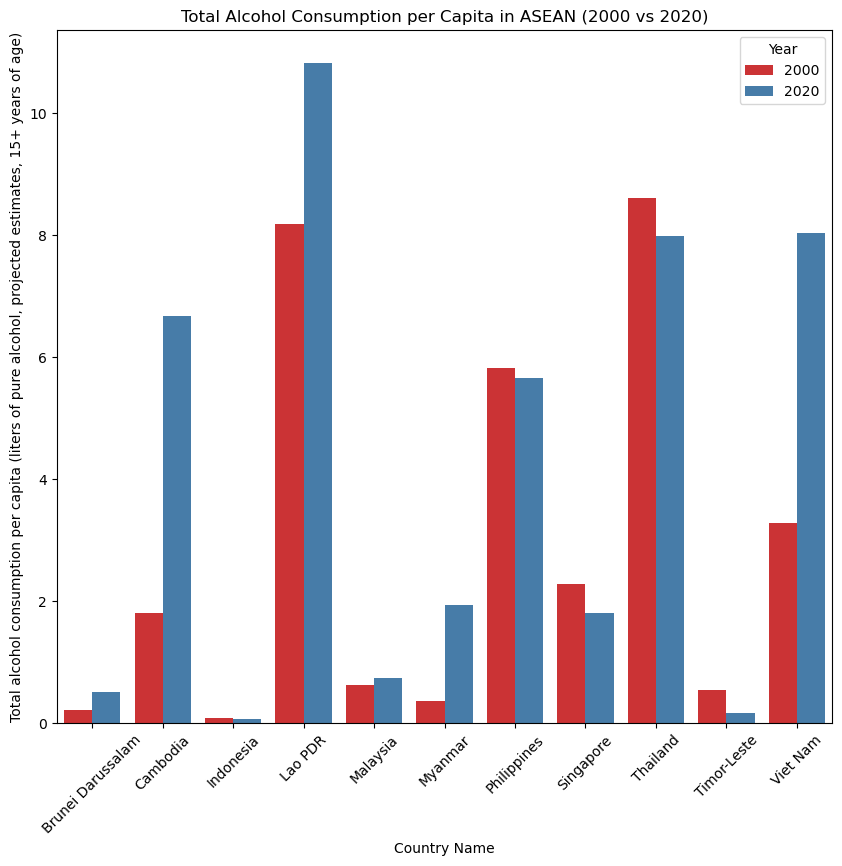

In [31]:
# Group bar chart for total alcohol consumption per capita (liters of pure alcohol, projected estimates, 15+ years of age)
df_alcohol = df_final[df_final["Year"].isin([2000, 2020])]
plt.figure(figsize=(10,9))
sns.barplot(
    data=df_alcohol,
    x="Country Name",
    y="Total alcohol consumption per capita (liters of pure alcohol, projected estimates, 15+ years of age)",
    hue="Year",
    palette="Set1"
)
plt.title("Total Alcohol Consumption per Capita in ASEAN (2000 vs 2020)")
plt.xticks(rotation=45)
plt.show()

- **Overview analysis:** The chart shows that changes in alcohol consumption habits across the region are heterogeneous, with some countries experiencing a sharp increase while others see a decrease.

- **Observations and trends drawn from the data:**
  - Thailand, Vietnam, and Laos had relatively high alcohol consumption in 2020 compared to the region. This could be due to the habits of people from these countries.
  - Alcohol consumption in Malaysia, Indonesia, Brunei, and Timor Leste is very low. This may be due to the geographical proximity of these countries, leading to similarities in consumption habits.
  - Vietnam, Cambodia, and Laos have seen a significant increase in consumption; these three countries are geographically close, so this could be due to similarities in consumption habits.
  - Thailand is a major beer consumer, but consumption has seen a slight decline over the past 20 years.
- **Inclusion:** It can be seen that the level of alcohol consumption in Southeast Asia generally does not significantly affect life expectancy, with Thailand and Vietnam having high life expectancy but relatively high consumption. In contrast, Myanmar has low consumption but a low life expectancy.

#### 4. When discussing healthcare, the issue of immunization rates needs to be addressed. The question is what is the correlation between immunization rates, healthcare budgets, and mortality rates among children under 5 years old and infants?

- **Data field:** 
  - `Mortality rate, under-5 (per 1,000 live births)`: This field contains values that representing the number of deaths among children under 5 years old per 1000 children in this age group in one year. This attribute is a matter of concern when it comes to children's health.
  - `Mortality rate, infant (per 1,000 live births)`: This field contains values that representing the number of deaths among infant per 1000 children in this age group in one year. This attribute is a matter of concern when it comes to children's health.
  - `Immunization, HepB3 (% of one-year-old children)`: This field contains values that representing The coverage rate of the three primary vaccine doses in 1-year-old children. Comparing alcohol content helps determine the impact of alcohol on health.
  - `Current health expenditure per capita, PPP (current international $)`: This field contains values representing the amount of money an average person spends on healthcare expenses in a year. This cost reflects the money spent by individuals, not the government.
- **Chart type:** 
  - Bubble chart (X-Axis is value of `Country Name`, Y-Axis is value of `Mortality caused by road traffic injury (per 100,000 population)`, A bubble represents a data point over a year, Colors represent each `Countryy Name` and the size of each bubble represents `Current health expenditure per capita, PPP (current international $)`) The chart shows the correlation between healthcare budget, vaccine coverage, and mortality rates among children under 5 years old.
  - Bubble chart (X-Axis is value of `Country Name`, Y-Axis is value of `Mortality rate, infant (per 1,000 live births)`, A bubble represents a data point over a year, Colors represent each `Countryy Name` and the size of each bubble represents `Current health expenditure per capita, PPP (current international $)`) The chart shows the correlation between healthcare budget, vaccine coverage, and mortality rates among children under 5 years old.
- **Expected insight:** The trends and correlations in healthcare investment for children across countries can be observed.

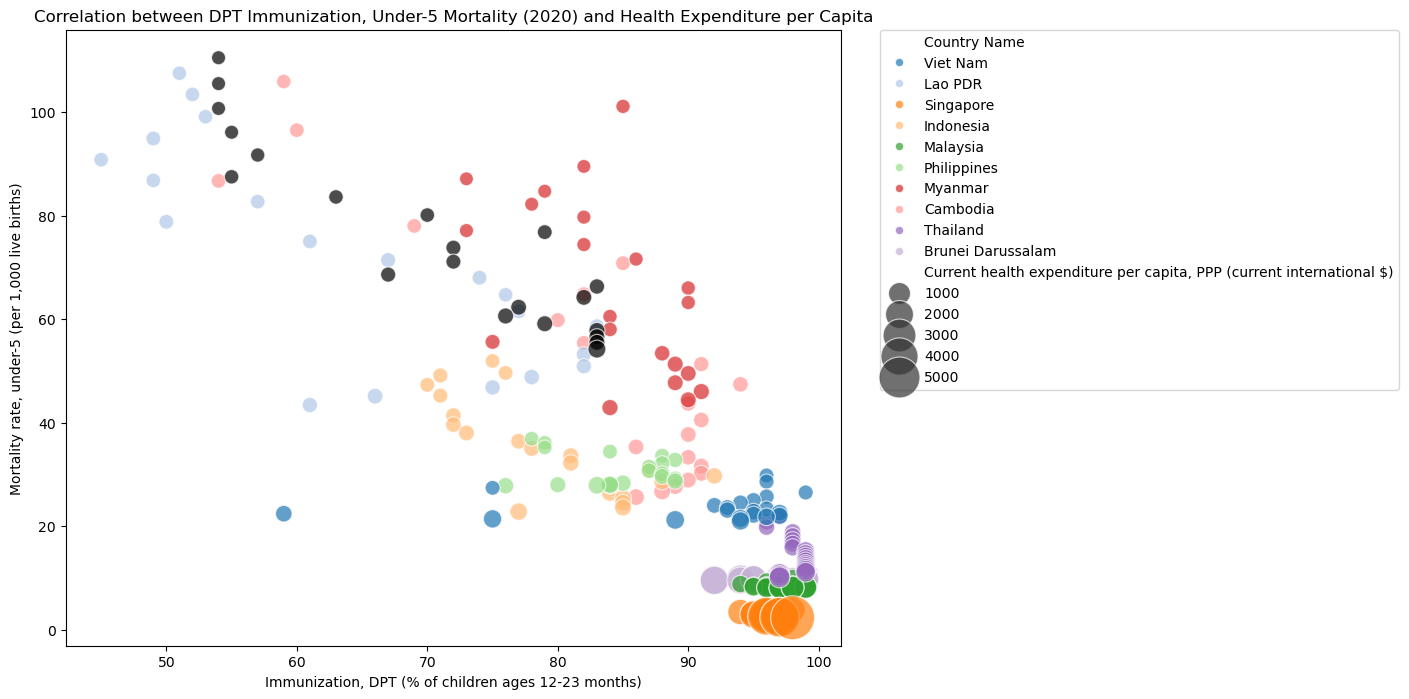

In [32]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_final, 
                x='Immunization, DPT (% of children ages 12-23 months)', 
                y='Mortality rate, under-5 (per 1,000 live births)',
                size='Current health expenditure per capita, PPP (current international $)', 
                hue='Country Name', 
                sizes=(100, 1000), 
                alpha=0.7,
                palette='tab20',
                hue_order=my_order)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title('Correlation between DPT Immunization, Under-5 Mortality (2020) and Health Expenditure per Capita')
plt.show()

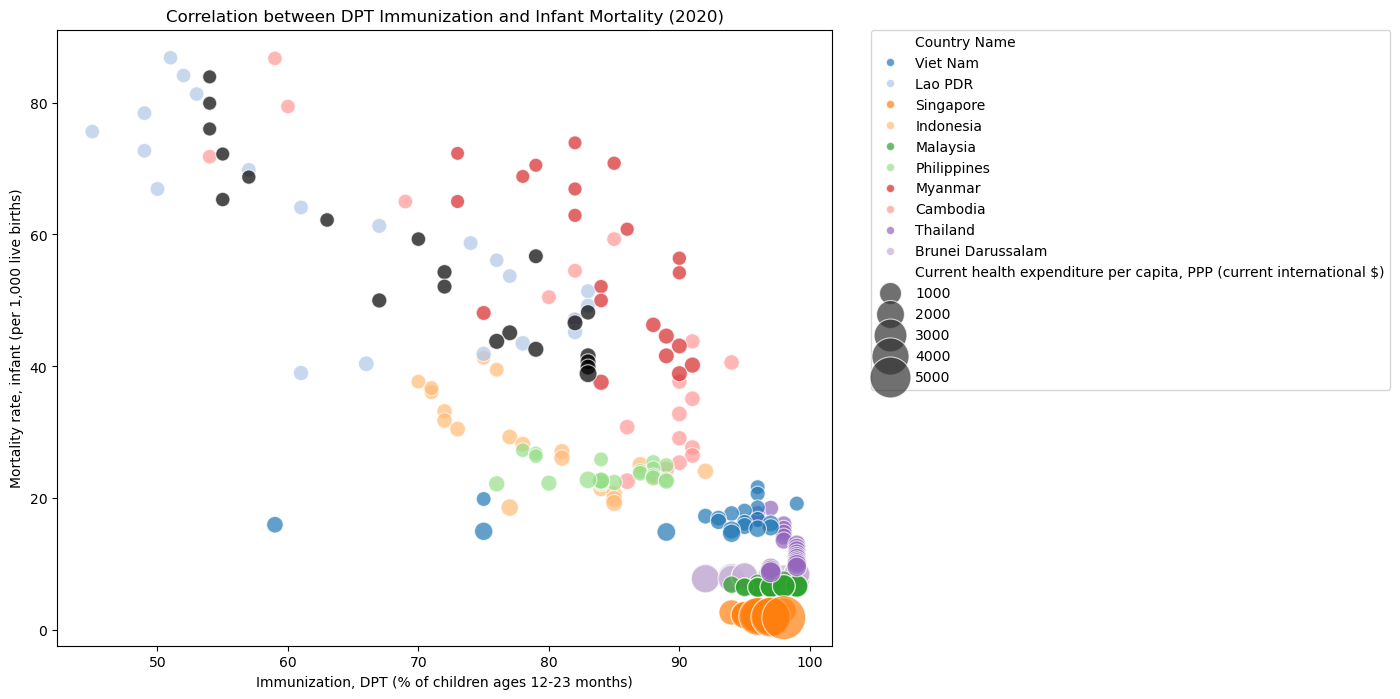

In [33]:
plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_final, 
                x='Immunization, DPT (% of children ages 12-23 months)', 
                y='Mortality rate, infant (per 1,000 live births)',
                size='Current health expenditure per capita, PPP (current international $)', 
                hue='Country Name', 
                sizes=(100, 1000), 
                alpha=0.7,
                palette='tab20',
                hue_order=my_order)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title('Correlation between DPT Immunization and Infant Mortality (2020)')
plt.show()

- **Overview analysis:** Overall, these two charts are 99% identical. These chart shows a trend of country bubbles oriented toward the bottom right corner, which may indicate concern about vaccine coverage in the region.

- **Observations and trends drawn from the data:**
  - As can be seen in the bottom right corner, countries like Singapore, Thailand, Brunei, and Malaysia are concentrated with larger bubbles compared to the rest, indicating that investment in healthcare is prioritized and yields significant results.
  - Vietnam is approaching this group in terms of coverage, having reached a rate close to that of this group, but the mortality rate remains high.
  - The remaining countries showed improvement, but mainly in terms of coverage rates ranging from 60% to 90%.
- **Inclusion:** Investment in forest cover in East Asia has improved, but there remains a gap between high-investment groups and the rest of the region.

#### 5. In the final research objective of this topic, we posed the question of how health indicators differ between men and women across countries in 2020?

- **Data field:** 
  - `Life expectancy at birth, male (years)`: This field contains values that representing Average lifespan of men in one year. This attribute would be suitable for health research purposes between the sexes.
  - `Life expectancy at birth, female (years)`: This field contains values that representing Average lifespan of women in one year. This attribute would be suitable for health research purposes between the sexes.
  - `Mortality from CVD, cancer, diabetes or CRD between exact ages 30 and 70, male (%)`: This field contains values that representing the mortality rate of men from non-communicable diseases such as heart disease, cancer, and diabetes over one year. This attribute will help assess how disease impacts gender.
  - `Mortality from CVD, cancer, diabetes or CRD between exact ages 30 and 70, female (%)`: This field contains values that representing the mortality rate of women from non-communicable diseases such as heart disease, cancer, and diabetes over one year. This attribute will help assess how disease impacts gender.
  - `Total alcohol consumption per capita, male (liters of pure alcohol, projected estimates, male 15+ years of age)`: This field contains values that average total alcohol consumption per male over 15 years old. Alcohol is a significant issue affecting health.
  - `Total alcohol consumption per capita, female (liters of pure alcohol, projected estimates, female 15+ years of age)`: This field contains values that average total alcohol consumption per female over 15 years old. Alcohol is a significant issue affecting health.
- **Chart type:** 
  - Dumbbell plot chart (X-Axis is value of life expectancy, Y-Axis is value of `Country Name`, Each point is data about `Life expectancy at birth, male (years)` or `Life expectancy at birth, female (years)`, the line connecting the two points shows the difference between the two attributes) This chart will show the difference in life expectancy between men and women in various countries in 2020.
  - Dumbbell plot chart (X-Axis is value of life expectancy, Y-Axis is value of `Country Name`, Each point is data about `Mortality from CVD, cancer, diabetes or CRD between exact ages 30 and 70, male (%)` or `Mortality from CVD, cancer, diabetes or CRD between exact ages 30 and 70, female (%)`, the line connecting the two points shows the difference between the two attributes)The chart will show the difference in mortality rates for this disease group between the two sexes in different countries.
  - Dumbbell plot chart (X-Axis is value of life expectancy, Y-Axis is value of `Country Name`, Each point is data about `Total alcohol consumption per capita, male (liters of pure alcohol, projected estimates, male 15+ years of age)` or `Total alcohol consumption per capita, female (liters of pure alcohol, projected estimates, female 15+ years of age)`, the line connecting the two points shows the difference between the two attributes)The chart will show the difference in alcohol consumption between the two genders.
- **Expected insight:** Differences can be observed between men and women in health factors such as life expectancy, mortality rates from disease, and alcohol consumption.

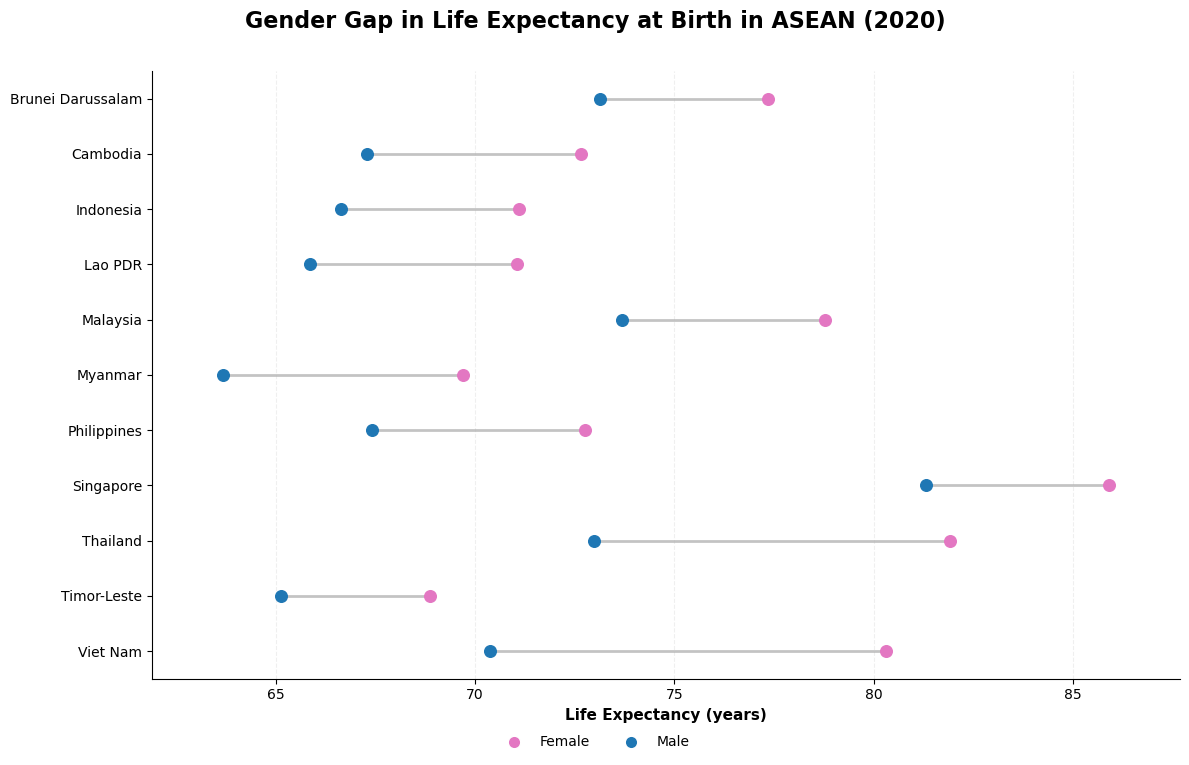

In [34]:
df_2020 = df_final[df_final["Year"] == 2020]

male_col = 'Life expectancy at birth, male (years)'
female_col = 'Life expectancy at birth, female (years)'

dumbbell_specs = [
    (female_col, male_col, "Life Expectancy"),
]

female_color = "#e377c2" 
male_color = "#1f77b4"  
country_order = sorted(df_2020['Country Name'].unique(), reverse=True)

x_limits = {}
for f_col, m_col, _ in dumbbell_specs:
    vals = pd.concat([df_2020[f_col], df_2020[m_col]], ignore_index=True).dropna()
    x_min, x_max = vals.min(), vals.max()

    x_pad = (x_max - x_min) * 0.08 if x_max > x_min else 2
    x_limits[(f_col, m_col)] = (x_min - x_pad, x_max + x_pad)

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor("white")

x_left, x_right = x_limits[(female_col, male_col)]

plot_df = df_2020[['Country Name', female_col, male_col]].dropna().copy()
plot_df = plot_df.set_index('Country Name').reindex(country_order).reset_index()
plot_df['y_pos'] = range(len(plot_df))

ax.hlines(
    y=plot_df["y_pos"],
    xmin=plot_df[female_col],
    xmax=plot_df[male_col],
    color="#B5B5B5",
    linewidth=2,
    alpha=0.8,
    zorder=1
)

ax.scatter(plot_df[female_col], plot_df["y_pos"], color=female_color, s=70, zorder=3)
ax.scatter(plot_df[male_col], plot_df["y_pos"], color=male_color, s=70, zorder=3)

ax.set_xlim(x_left, x_right)
ax.set_ylim(-0.5, len(country_order) - 0.5)
ax.set_yticks(range(len(country_order)))
ax.set_yticklabels(country_order, fontsize=10)

ax.set_xlabel("Life Expectancy (years)", fontsize=11, weight="bold")
ax.grid(axis="x", alpha=0.2, linestyle='--')
ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=female_color, markersize=9, label="Female"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=male_color, markersize=9, label="Male"),
]
fig.legend(
    handles=handles,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.02),
)

fig.suptitle(
    "Gender Gap in Life Expectancy at Birth in ASEAN (2020)",
    fontsize=16,
    weight="bold",
    y=0.96,
)

plt.tight_layout(rect=(0, 0.05, 1, 0.95))
plt.show()

- **Overview analysis:** Based on the chart, it can be seen that in all countries, women have a higher life expectancy than men.

- **Observations and trends drawn from the data:**
  - In most countries, there is a difference in life expectancy between the sexes of about 4-6 years.
  - However, Vietnam and Thailand have the largest difference in life expectancy between the two genders, at nearly 10 years. This may indicate that men in these two countries do not have access to adequate medical care, face more serious health problems, or lack self-care habits.
  - Women in Vietnam and Thailand live relatively long lives, averaging over 80 years old, close to the average age of men in Singapore.
  - Although Singapore has the highest life expectancy, the smallest gap is in Timor Leste, a country with the lowest life expectancy in the region.
- **Inclusion:** Southeast Asian countries show a certain degree of similarity in male-female life expectancy, but Vietnam and Thailand, in particular, have a large disparity compared to other countries.

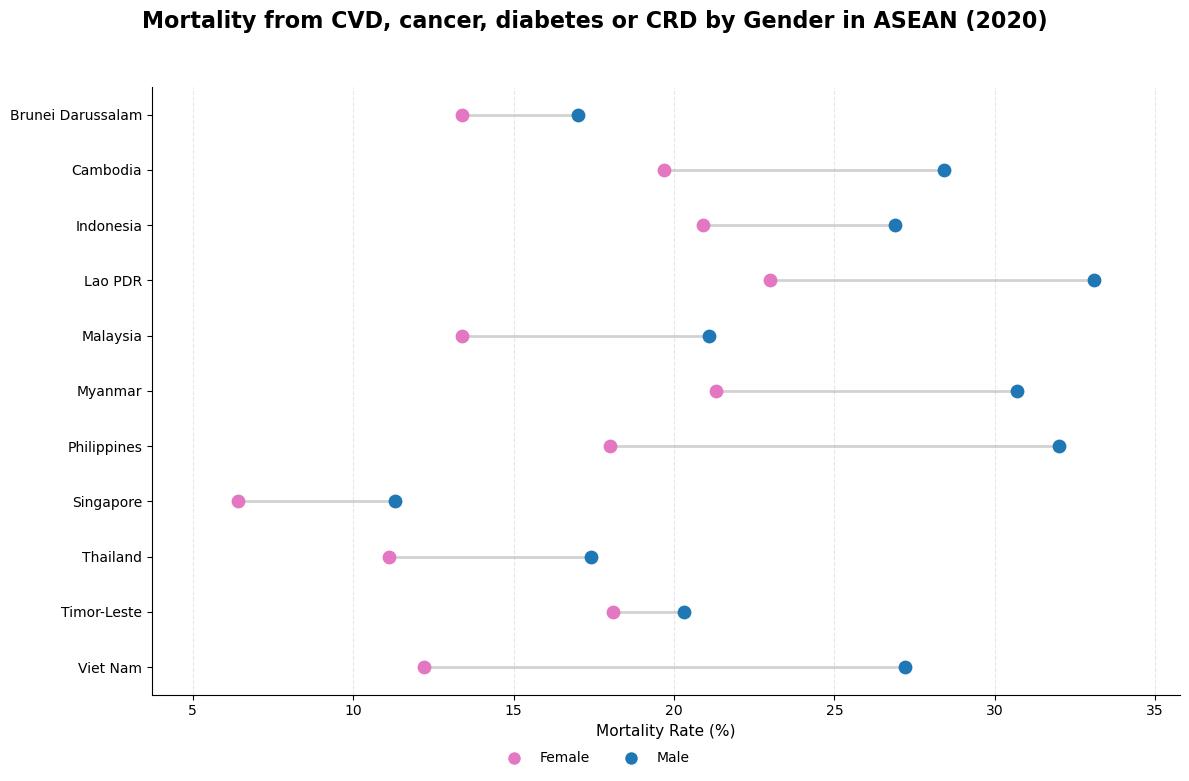

In [35]:
male_col = 'Mortality from CVD, cancer, diabetes or CRD between exact ages 30 and 70, male (%)'
female_col = 'Mortality from CVD, cancer, diabetes or CRD between exact ages 30 and 70, female (%)'

dumbbell_specs = [
    (female_col, male_col, "NCD Mortality Rate"),
]

female_color = "#e377c2" 
male_color = "#1f77b4"  
country_order = sorted(df_2020['Country Name'].unique(), reverse=True)

x_limits = {}
for f_col, m_col, _ in dumbbell_specs:
    vals = pd.concat([df_2020[f_col], df_2020[m_col]], ignore_index=True).dropna()
    x_min, x_max = vals.min(), vals.max()
    x_pad = (x_max - x_min) * 0.1 if x_max > x_min else 5
    x_limits[(f_col, m_col)] = (max(0, x_min - x_pad), x_max + x_pad)

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
fig.patch.set_facecolor("white")

x_left, x_right = x_limits[(female_col, male_col)]

plot_df = df_2020[['Country Name', female_col, male_col]].dropna().copy()
plot_df = plot_df.set_index('Country Name').reindex(country_order).reset_index()
plot_df['y_pos'] = range(len(plot_df))

ax.hlines(
    y=plot_df["y_pos"],
    xmin=plot_df[female_col],
    xmax=plot_df[male_col],
    color="#B5B5B5",
    linewidth=2,
    alpha=0.6,
    zorder=1
)

ax.scatter(plot_df[female_col], plot_df["y_pos"], color=female_color, s=80, label="Female", zorder=3)
ax.scatter(plot_df[male_col], plot_df["y_pos"], color=male_color, s=80, label="Male", zorder=3)

ax.set_xlim(x_left, x_right)
ax.set_yticks(range(len(country_order)))
ax.set_yticklabels(country_order)
ax.set_xlabel("Mortality Rate (%)", fontsize=11)
ax.grid(axis="x", alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=female_color, markersize=10, label="Female"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=male_color, markersize=10, label="Male"),
]
fig.legend(
    handles=handles,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.02),
)

fig.suptitle(
    "Mortality from CVD, cancer, diabetes or CRD by Gender in ASEAN (2020)",
    fontsize=16,
    weight="bold",
    y=0.98,
)

plt.tight_layout(rect=(0, 0.05, 1, 0.95))
plt.show()

- **Overview analysis:** It can be observed that the mortality rate from non-communicable diseases diseases is similar between the two sexes in countries in the region, with men generally having a higher mortality rate than women.

- **Observations and trends drawn from the data:**
  - The wide range of mortality rates, from low to high, indicates a significant gap between the sexes across countries.
  - The Philippines and Vietnam have a relatively large difference in sex mortality rates compared to the region, at around 15%.
  - In contrast, countries with smaller populations like Singapore, Brunei, and Timor-Leste show very little difference, at around 2-3%.
  - Although Thailand has a high life expectancy gap, the difference in mortality rates for this disease group between the two sexes is only average for the region.
  - Developed countries have better disease control, and lifestyle and behavior are important factors influencing this difference.
- **Inclusion:** 
  - Men have a higher mortality rate from non-communicable diseases than women in all ASEAN countries.
  - Developed countries have better disease control, and lifestyle and behavior are important factors influencing this difference.

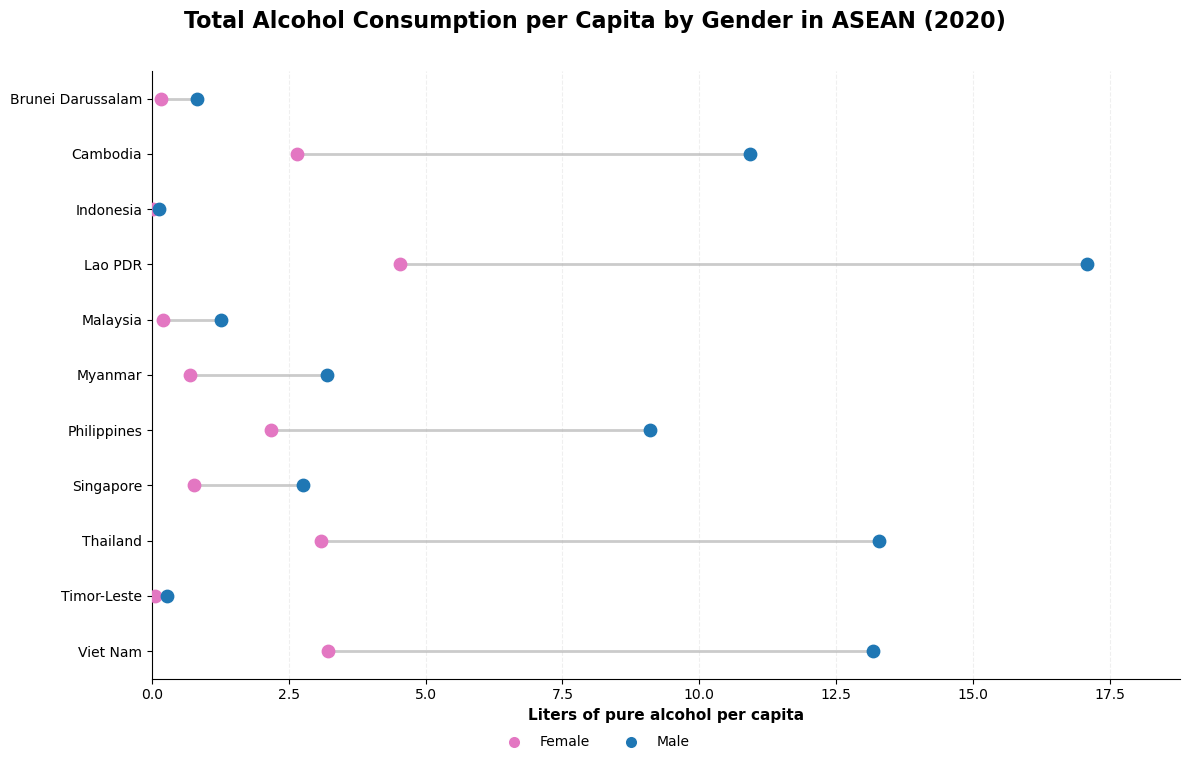

In [36]:
male_col = 'Total alcohol consumption per capita, male (liters of pure alcohol, projected estimates, male 15+ years of age)'
female_col = 'Total alcohol consumption per capita, female (liters of pure alcohol, projected estimates, female 15+ years of age)'

dumbbell_specs = [
    (female_col, male_col, "Alcohol Consumption"),
]

female_color = "#e377c2" 
male_color = "#1f77b4"   
country_order = sorted(df_2020['Country Name'].unique(), reverse=True)

x_limits = {}
for f_col, m_col, _ in dumbbell_specs:
    vals = pd.concat([df_2020[f_col], df_2020[m_col]], ignore_index=True).dropna()
    x_min, x_max = vals.min(), vals.max()
    x_pad = (x_max - x_min) * 0.1 if x_max > x_min else 2
    x_limits[(f_col, m_col)] = (max(0, x_min - x_pad), x_max + x_pad)

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor("white")

x_left, x_right = x_limits[(female_col, male_col)]

plot_df = df_2020[['Country Name', female_col, male_col]].dropna().copy()
plot_df = plot_df.set_index('Country Name').reindex(country_order).reset_index()
plot_df['y_pos'] = range(len(plot_df))

ax.hlines(
    y=plot_df["y_pos"],
    xmin=plot_df[female_col],
    xmax=plot_df[male_col],
    color="#B5B5B5",
    linewidth=2,
    alpha=0.7,
    zorder=1
)

ax.scatter(plot_df[female_col], plot_df["y_pos"], color=female_color, s=80, zorder=3)
ax.scatter(plot_df[male_col], plot_df["y_pos"], color=male_color, s=80, zorder=3)

ax.set_xlim(x_left, x_right)
ax.set_ylim(-0.5, len(country_order) - 0.5)
ax.set_yticks(range(len(country_order)))
ax.set_yticklabels(country_order, fontsize=10)

ax.set_xlabel("Liters of pure alcohol per capita", fontsize=11, weight="bold")
ax.grid(axis="x", alpha=0.2, linestyle='--')
ax.set_axisbelow(True)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=female_color, markersize=9, label="Female"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=male_color, markersize=9, label="Male"),
]
fig.legend(
    handles=handles,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.02),
)

fig.suptitle(
    "Total Alcohol Consumption per Capita by Gender in ASEAN (2020)",
    fontsize=16,
    weight="bold",
    y=0.96,
)

plt.tight_layout(rect=(0, 0.05, 1, 0.95))
plt.show()

- **Overview analysis:** It can be observed that in all countries in the region, men consume more alcohol than women.

- **Observations and trends drawn from the data:**
  - The total amount of alcohol consumed varies greatly across countries, as analyzed above.
  - In countries with high alcohol consumption such as Vietnam, Cambodia, Laos, and Thailand, alcohol consumption among women is even higher than among men in many other countries in the region.
  - In these countries, there is a significant difference in alcohol consumption between the two sexes.
- **Inclusion:** 
  - Men consume more alcohol than women in all ASEAN countries.
  - The gender gap in alcohol consumption is very large in some countries.